In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn import svm
from sklearn.model_selection import train_test_split


In [ ]:
#df_train = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_Train_V2.txt', header=None)
#df_test = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_Test_V2.txt', header=None) #156m
df_Conjunt = pd.read_csv('/content/Conjunt_Normalitzat.txt',header=None)

In [ ]:

df_train, df_test = train_test_split(df_Conjunt, test_size=0.10, random_state=100)

E_Train = df_train.iloc[:, 0:7]
Etiqueta_Train = df_train.iloc[:, 7]

FE_Test = df_test.iloc[:, 0:7]
Etiqueta_Test = df_test.iloc[:, 7]


print(f"Tamany total: {len(df_Conjunt)}")
print(f"Tamany Train: {len(df_train)} | Tamany Test: {len(df_test)}")

Registros totales: 639
Registros Train: 575 | Registros Test: 64


In [ ]:
FE_Train = df_train.iloc[:, 0:7]
Etiqueta_Train = df_train.iloc[:, 7]
FE_Test = df_test.iloc[:, 0:7]
Etiqueta_Test = df_test.iloc[:, 7]

In [ ]:
from sklearn import svm
clf = svm.SVC(kernel='linear', C=1)
#clf = svm.SVC(kernel='rbf', C=12, gamma= 'auto') #'auto'
#clf = svm.SVC(kernel='poly', C=1, degree=3)
clf.fit(FE_Train, Etiqueta_Train)
predict = clf.predict(FE_Test)


In [ ]:
from sklearn import metrics
print("Accuracy:",metrics.accuracy_score(Etiqueta_Test, predict))

Accuracy: 0.921875


In [ ]:
from sklearn import metrics

print("Precisió:", metrics.precision_score(Etiqueta_Test, predict, average='weighted'))

print("Recall:", metrics.recall_score(Etiqueta_Test, predict, average='weighted'))

print("F1-Score:", metrics.f1_score(Etiqueta_Test, predict, average='weighted'))

Precision: 0.9368990384615385
Recall: 0.921875
F1-Score: 0.9223847517730497


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(Etiqueta_Test, predict))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       1.00      0.80      0.89        20
           2       0.81      1.00      0.89        21

    accuracy                           0.92        64
   macro avg       0.94      0.92      0.92        64
weighted avg       0.94      0.92      0.92        64



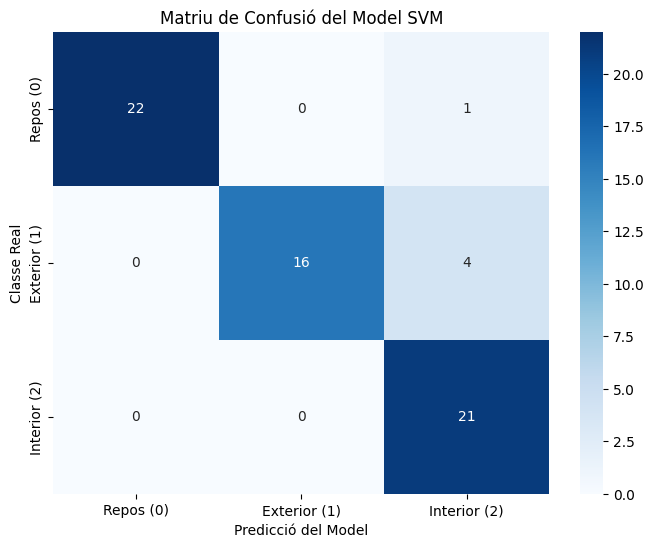

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generar la matriu de confusió numèrica
cm = confusion_matrix(Etiqueta_Test, predict)

# 2. Configurar la visualització
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repos (0)', 'Exterior (1)', 'Interior (2)'],
            yticklabels=['Repos (0)', 'Exterior (1)', 'Interior (2)'])

plt.xlabel('Predicció del Model')
plt.ylabel('Classe Real')
plt.title('Matriu de Confusió del Model SVM')
plt.show()

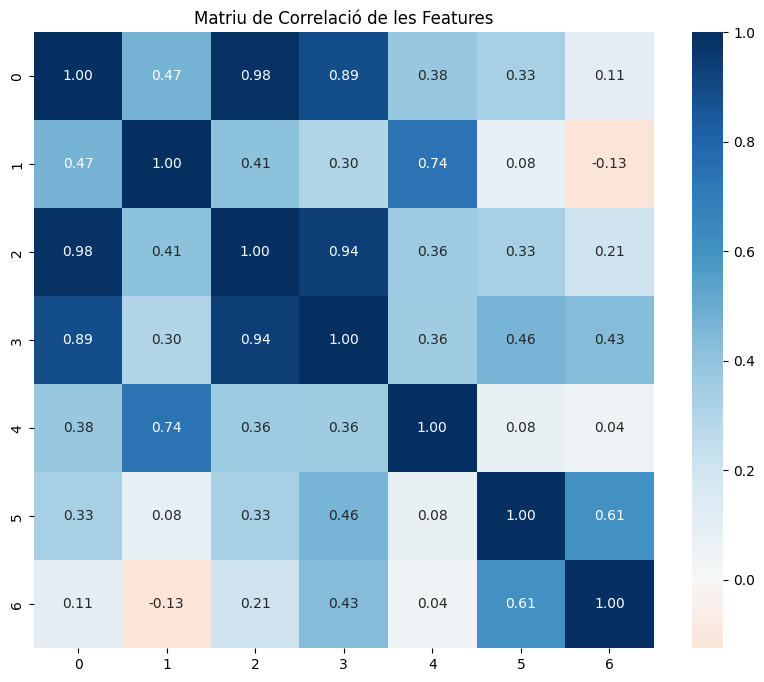

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculem la matriu de correlació només de les característiques (FE)
corr_matrix = FE_Train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Matriu de Correlació de les Features')
plt.show()

In [ ]:
#K-Fold Cross-Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, FE_Train, Etiqueta_Train, cv=10)
print(f"Accuracy mitjana: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Accuracy mitjana: 0.95 (+/- 0.04)


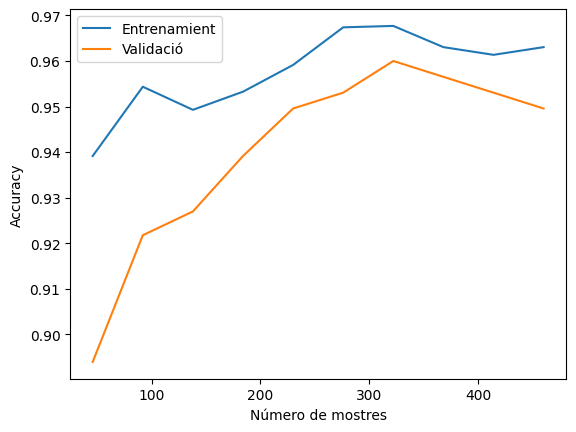

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    clf, FE_Train, Etiqueta_Train, cv=5, train_sizes=np.linspace(0.1, 1.0, 10))

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Entrenament')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validació')
plt.xlabel('Número de mostres')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Extreure Pesos (Weights) i Bias
weights = clf.coef_
bias = clf.intercept_

print("Pesos (W):\n", weights)
print("Bias (b):\n", bias)

Pesos (W):
 [[-2.48034033  0.11212455 -1.10545507 -1.04048779 -0.19900071 -1.36819265
   0.82353578]
 [-1.77942692  0.06294023 -0.58432685 -1.27357369 -0.53066175  0.31222742
  -0.22674487]
 [ 2.03278852  0.40560687  2.22696351 -4.8411432  -0.71682096  1.54048824
  -0.3479578 ]]
Bias (b):
 [-2.80727151 -1.39952904  0.06097139]
